In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- SECTION 1: DATA INGESTION & CLEANING ---
raw_df = pd.read_csv("RAW_EduPath_Data.csv")
clean_df = raw_df.drop_duplicates().copy()

# Standardizing UAE University names from our Top 20 verified list
clean_df['Target_Uni'] = clean_df['Target_Uni'].replace({
    'University of Wollongong Dubai': 'UOWD', 'uowd': 'UOWD',
    'Am. Uni Sharjah': 'AUS', 'Khalifa Uni': 'KU'
})
clean_df['Gender'] = clean_df['Gender'].str.upper().map({'MALE':'M', 'M':'M', 'FEMALE':'F', 'F':'F'})
clean_df['Math'] = clean_df['Math'].fillna(clean_df['Math'].median())



In [ ]:
# --- SECTION 2: FEATURE ENGINEERING ---
clean_df['STEM_Strength'] = (clean_df['Math'] + clean_df['Phys']) / 2
clean_df['Academic_Readiness'] = (clean_df['STEM_Strength'] + clean_df['Eng']) / 2
clean_df.to_csv("CLEANED_EduPath_Data.csv", index=False)

In [ ]:
# --- SECTION 3: PATHWAY PREDICTION MODEL (MODEL A) ---
le_pathway = LabelEncoder()
clean_df['Pathway_Encoded'] = le_pathway.fit_transform(clean_df['Pathway'])

X = clean_df[['Math', 'Phys', 'Eng', 'ICT', 'EmSAT_Eng', 'STEM_Strength', 'Academic_Readiness']]
y_path = clean_df['Pathway_Encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y_path, test_size=0.2, random_state=42)

# Hyperparameter Tuning for Optimization
param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
path_model = grid_search.best_estimator_

In [ ]:
# --- SECTION 4: UNIVERSITY RECOMMENDATION MODEL (MODEL B) ---
foundation_data = clean_df[clean_df['Pathway'] == 'Foundation'].copy()
le_uni = LabelEncoder()
foundation_data['Uni_Encoded'] = le_uni.fit_transform(foundation_data['Target_Uni'])

X_uni = foundation_data[['Math', 'Phys', 'Eng', 'ICT', 'EmSAT_Eng', 'STEM_Strength', 'Academic_Readiness']]
y_uni = foundation_data['Uni_Encoded']
uni_model = RandomForestClassifier(n_estimators=100, random_state=42)
uni_model.fit(X_uni, y_uni)


RandomForestClassifier(random_state=42)

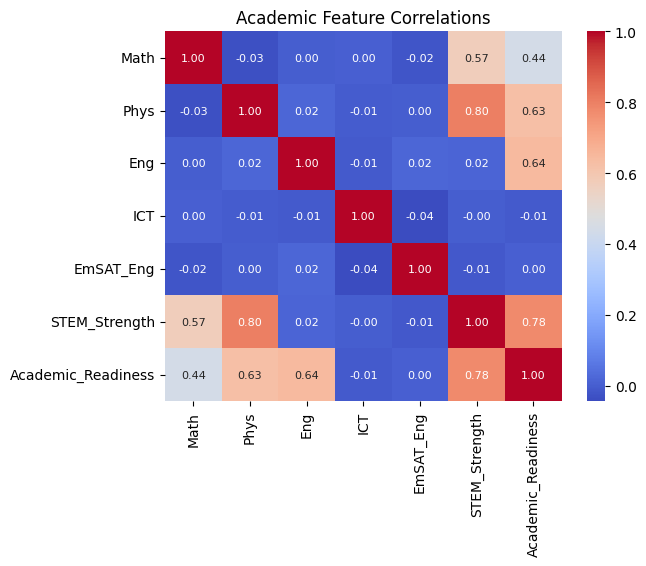

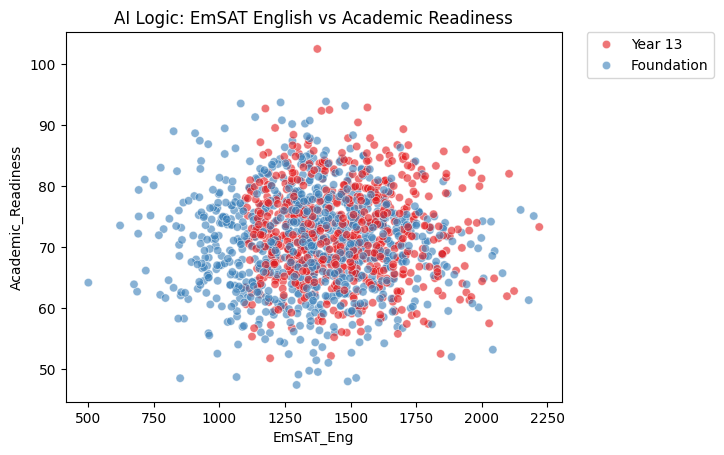

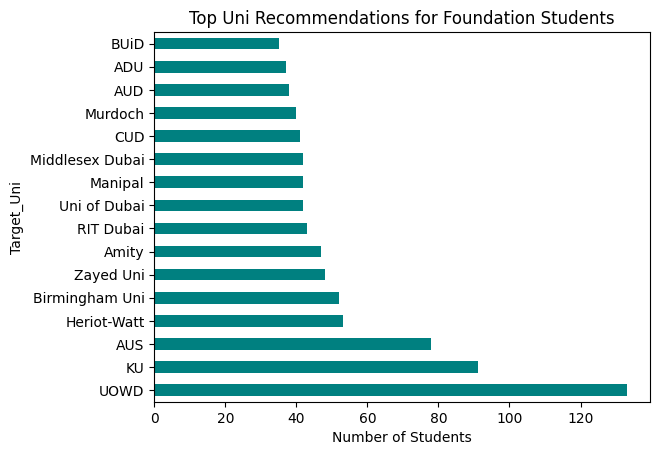

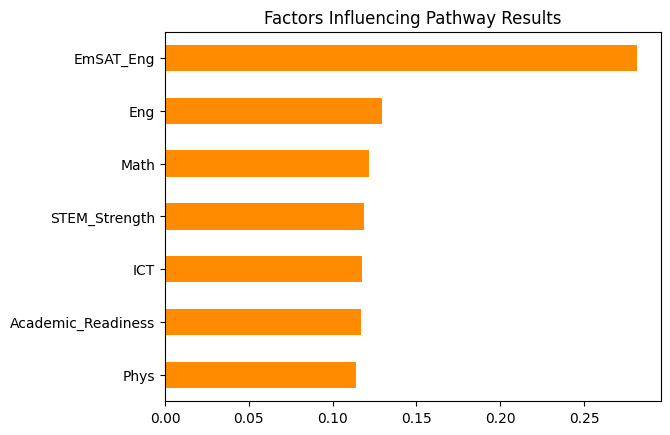

In [ ]:
# --- SECTION 5: COMPACT DATA VISUALIZATION MODULE ---

# 1. Correlation Heatmap
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Academic Feature Correlations', fontsize=12)
plt.savefig('Correlation_Heatmap.png')
plt.show()

# 2. Decision Logic (Scatter Plot)
sns.scatterplot(x='EmSAT_Eng', y='Academic_Readiness', hue='Pathway', data=clean_df, palette='Set1', alpha=0.6)
plt.title('AI Logic: EmSAT English vs Academic Readiness', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.savefig('Decision_Logic.png', bbox_inches='tight')
plt.show()

# 3. Uni Popularity (Horizontal Bar)
foundation_data['Target_Uni'].value_counts().plot(kind='barh', color='teal')
plt.title('Top Uni Recommendations for Foundation Students', fontsize=12)
plt.xlabel('Number of Students', fontsize=10)
plt.savefig('Uni_Recommendations.png', bbox_inches='tight')
plt.show()

# 4. Feature Importance
feat_importances = pd.Series(path_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='darkorange')
plt.title('Factors Influencing Pathway Results', fontsize=12)
plt.savefig('Feature_Importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- SECTION 6: FINAL PROJECT PERFORMANCE REPORT ---
print("==================================================")
print("   CSCI323 PROJECT PERFORMANCE REPORT (WINTER 2026)")
print("==================================================")
print(f"1. OPTIMIZATION: Best Model Parameters: {grid_search.best_params_}")
print(f"2. ACCURACY: Overall Pathway Prediction Accuracy: {accuracy_score(y_test, path_model.predict(X_test))*100:.2f}%")
print("\n3. CLASSIFICATION BREAKDOWN:")
print(classification_report(y_test, path_model.predict(X_test), target_names=le_pathway.classes_))

# Fixed Section 4: Data Mining Summary with correct column references
print("\n4. DATA MINING SUMMARY:")
print(f"- Total Raw Records Processed: {len(raw_df)}")
print(f"- Cleaned Unique Records: {len(clean_df)}")

# Using a safe check for the Math column name
math_col = 'Math_Score' if 'Math_Score' in raw_df.columns else 'Math'
missing_math = raw_df[math_col].isnull().sum()
print(f"- Missing Math Grades Imputed: {missing_math}")
print("==================================================")

   CSCI323 PROJECT PERFORMANCE REPORT (WINTER 2026)
1. OPTIMIZATION: Best Model Parameters: {'max_depth': 10, 'n_estimators': 200}
2. ACCURACY: Overall Pathway Prediction Accuracy: 63.00%

3. CLASSIFICATION BREAKDOWN:
              precision    recall  f1-score   support

  Foundation       0.65      0.76      0.70       169
     Year 13       0.60      0.46      0.52       131

    accuracy                           0.63       300
   macro avg       0.62      0.61      0.61       300
weighted avg       0.63      0.63      0.62       300


4. DATA MINING SUMMARY:
- Total Raw Records Processed: 1600
- Cleaned Unique Records: 1500
- Missing Math Grades Imputed: 72
